# Notebook 02: Synthetic Pool Quality Data Generator

**Module B** of the smart-facility-pulse pilot.

Generates 90 days of hourly readings for:
- **Main Pool** — adult/family pool, larger volume, higher usage
- **Kids Pool** — smaller, warmer, faster chemistry degradation

Sensors (CDC-aligned):
- Water temperature (°C)
- pH
- Free chlorine (ppm)
- Turbidity (NTU)
- Pump runtime (hours since last service)

Includes realistic service cycles + 2 deliberate "service overdue" stories for the demo.

Output: `pool_sensors.parquet` saved to Google Drive.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
import os

from google.colab import drive
drive.mount('/content/drive')

PROJECT_ROOT = '/content/drive/MyDrive/smart-facility-pulse'
DATA_DIR = os.path.join(PROJECT_ROOT, 'data', 'synthetic')
os.makedirs(DATA_DIR, exist_ok=True)

# Different seed than Notebook 01 so pool randomness is independent
np.random.seed(123)

# Reuse the same time range as Notebook 01 (so pool & comfort align in dashboard)
END_DATE = datetime(2026, 5, 2, 23, 0, 0)
START_DATE = END_DATE - timedelta(days=90)
TIMESTAMPS = pd.date_range(start=START_DATE, end=END_DATE, freq='h')

# Load outdoor weather (already generated) — pools react to outdoor temp
weather_df = pd.read_parquet(os.path.join(DATA_DIR, 'outdoor_weather.parquet'))

print(f"✓ Time range: {START_DATE.date()} → {END_DATE.date()}")
print(f"✓ Hours per pool: {len(TIMESTAMPS):,}")
print(f"✓ Loaded outdoor weather: {len(weather_df):,} rows")

Mounted at /content/drive
✓ Time range: 2026-02-01 → 2026-05-02
✓ Hours per pool: 2,161
✓ Loaded outdoor weather: 2,161 rows


In [2]:
pools = pd.DataFrame([
    {
        'pool_id': 'POOL-MAIN',
        'pool_name': 'Main Pool',
        'volume_m3': 180,                # standard residential rooftop pool
        'temp_setpoint': 28.0,           # comfortable adult swimming temp
        'baseline_usage': 0.40,          # higher daytime usage
        'service_interval_hours': 168,   # weekly service cycle
    },
    {
        'pool_id': 'POOL-KIDS',
        'pool_name': 'Kids Pool',
        'volume_m3': 35,                 # much smaller
        'temp_setpoint': 30.0,           # kept warmer
        'baseline_usage': 0.55,          # heavier proportional usage = faster fouling
        'service_interval_hours': 120,   # serviced more often (every 5 days)
    },
])
print("✓ Pool master table:")
pools

✓ Pool master table:


,pool_id,pool_name,volume_m3,temp_setpoint,baseline_usage,service_interval_hours
0,POOL-MAIN,Main Pool,180,28.0,0.40,168
1,POOL-KIDS,Kids Pool,35,30.0,0.55,120


In [3]:
def build_service_schedule(n_hours, interval_hours, overdue_at_end=False):
    """
    Returns array of 'hours since last service' for each timestamp.
    If overdue_at_end is True, the last service is delayed (story for demo).
    """
    hours_since = np.zeros(n_hours)
    last_service = 0

    # Regular service every `interval_hours` until ~10 days before end
    cutoff = n_hours - (10 * 24) if overdue_at_end else n_hours

    for i in range(n_hours):
        if i >= cutoff:
            # No more services — let it degrade
            hours_since[i] = i - last_service
        else:
            if (i - last_service) >= interval_hours:
                last_service = i
            hours_since[i] = i - last_service

    return hours_since

In [4]:
def generate_pool_readings(pool_row, weather_df, timestamps, overdue_story=False):
    n = len(timestamps)
    hours = np.array([t.hour for t in timestamps])
    days = np.array([t.dayofweek for t in timestamps])

    # --- Service cycle ---
    hours_since_service = build_service_schedule(
        n, pool_row['service_interval_hours'], overdue_at_end=overdue_story
    )

    # --- Usage pattern ---
    # Pool usage peaks: morning (7-10am) + late afternoon (4-8pm)
    morn = np.exp(-((hours - 8) ** 2) / 6)
    aft = np.exp(-((hours - 18) ** 2) / 8)
    time_factor = 0.1 + morn + aft

    # Hot days = more swimmers
    temp_boost = np.clip((weather_df['outdoor_temp'].values - 25) / 10, 0, 1.5)
    weekend_boost = np.where(days >= 5, 1.4, 1.0)
    usage = pool_row['baseline_usage'] * time_factor * weekend_boost * (1 + temp_boost)
    usage += np.random.normal(0, 0.05, n)
    usage = np.clip(usage, 0, 1.5)

    # --- Water Temperature ---
    # Pool heaters maintain setpoint, but small drift with outdoor temp + usage
    setpoint = pool_row['temp_setpoint']
    outdoor_drift = 0.05 * (weather_df['outdoor_temp'].values - 28)
    water_temp = setpoint + outdoor_drift + np.random.normal(0, 0.4, n)

    # --- pH (drifts UP without service; CDC range 7.2-7.8) ---
    # Each service resets to ~7.4, then drift +0.05 per day on average
    pH_drift_rate = 0.0021  # per hour → ~0.05/day
    pH = 7.35 + pH_drift_rate * hours_since_service
    pH += 0.15 * usage              # heavy usage pushes pH up faster
    pH += np.random.normal(0, 0.04, n)
    pH = np.clip(pH, 6.8, 8.6)

    # --- Free Chlorine (depletes; CDC minimum 1 ppm) ---
    # Reset to ~2.5 ppm at service, depletes ~0.15 ppm/day, faster with usage + heat
    chlorine_decay_rate = 0.0063  # per hour → ~0.15/day
    chlorine = 2.5 - chlorine_decay_rate * hours_since_service
    chlorine -= 0.4 * usage         # swimmer load consumes chlorine
    chlorine -= 0.02 * np.maximum(water_temp - 28, 0)  # heat accelerates loss
    chlorine += np.random.normal(0, 0.08, n)
    chlorine = np.clip(chlorine, 0, 4.0)

    # --- Turbidity (climbs without filtration/service; clear water < 0.5 NTU) ---
    turb_growth_rate = 0.0042  # per hour
    turbidity = 0.2 + turb_growth_rate * hours_since_service
    turbidity += 0.6 * usage
    turbidity += np.random.normal(0, 0.08, n)
    turbidity = np.clip(turbidity, 0.1, 5.0)

    # --- Pump runtime (cumulative hours, resets at service) ---
    pump_runtime = hours_since_service * np.random.uniform(0.85, 0.95)

    return pd.DataFrame({
        'timestamp': timestamps,
        'pool_id': pool_row['pool_id'],
        'pool_name': pool_row['pool_name'],
        'water_temp': np.round(water_temp, 2),
        'pH': np.round(pH, 2),
        'chlorine': np.round(chlorine, 2),
        'turbidity': np.round(turbidity, 2),
        'pump_runtime': np.round(pump_runtime, 1),
        'hours_since_service': hours_since_service.astype(int),
        'usage_estimate': np.round(usage, 3),
    })

# Generate both pools
print("Generating pool data...")
main = generate_pool_readings(pools.iloc[0], weather_df, TIMESTAMPS, overdue_story=False)
kids = generate_pool_readings(pools.iloc[1], weather_df, TIMESTAMPS, overdue_story=True)

pool_sensor_df = pd.concat([main, kids], ignore_index=True)
print(f"✓ Total rows: {len(pool_sensor_df):,}")
print(f"✓ Columns: {list(pool_sensor_df.columns)}")
pool_sensor_df.head()

Generating pool data...
✓ Total rows: 4,322
✓ Columns: ['timestamp', 'pool_id', 'pool_name', 'water_temp', 'pH', 'chlorine', 'turbidity', 'pump_runtime', 'hours_since_service', 'usage_estimate']


,timestamp,pool_id,pool_name,water_temp,pH,chlorine,turbidity,pump_runtime,hours_since_service,usage_estimate
0,2026-02-01 23:00:00,POOL-MAIN,Main Pool,28.09,7.35,2.55,0.20,0.0,0,0.026
1,2026-02-02 00:00:00,POOL-MAIN,Main Pool,27.37,7.29,2.51,0.19,0.9,1,0.090
2,2026-02-02 01:00:00,POOL-MAIN,Main Pool,27.84,7.32,2.56,0.10,1.7,2,0.054
3,2026-02-02 02:00:00,POOL-MAIN,Main Pool,27.25,7.37,2.55,0.13,2.6,3,0.000
4,2026-02-02 03:00:00,POOL-MAIN,Main Pool,27.80,7.40,2.65,0.15,3.4,4,0.017


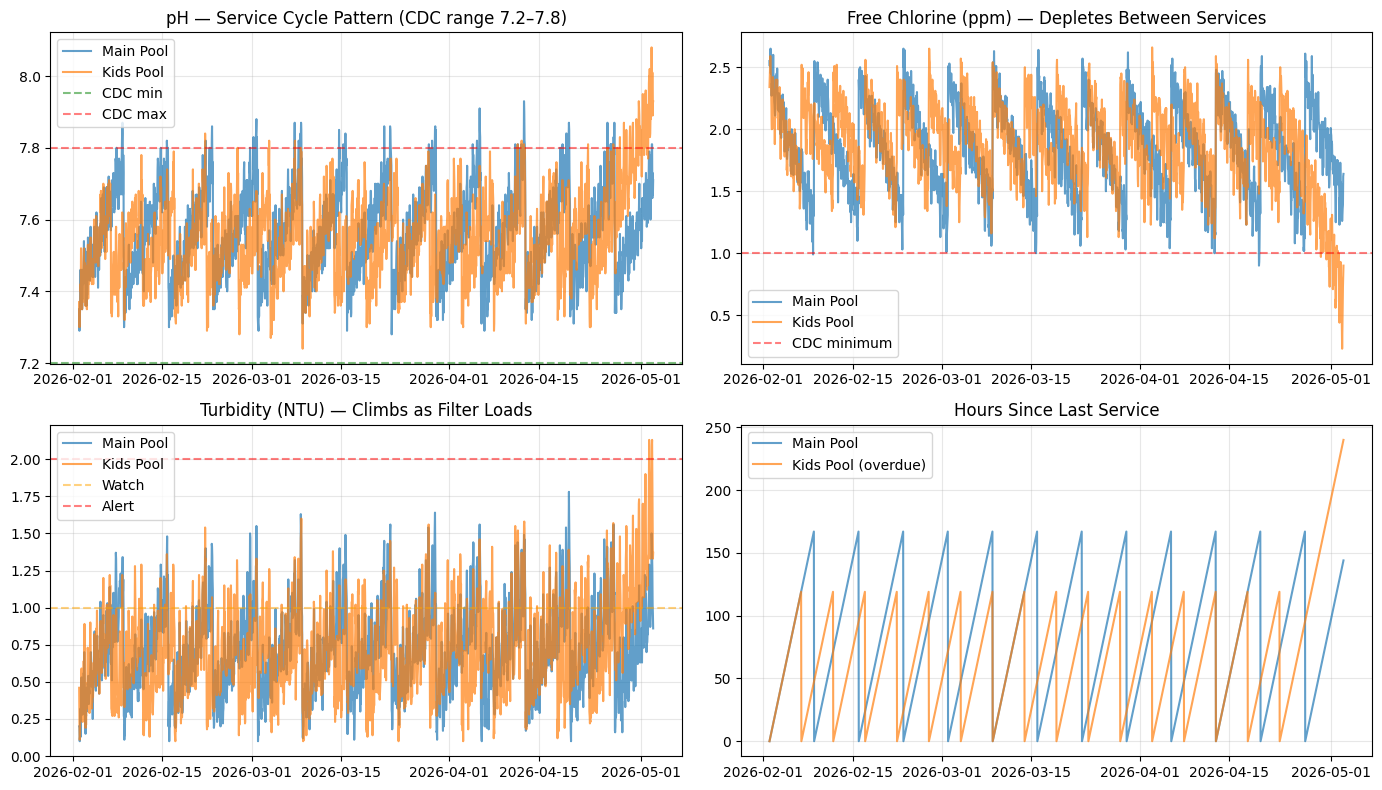

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

main_data = pool_sensor_df[pool_sensor_df['pool_id'] == 'POOL-MAIN']
kids_data = pool_sensor_df[pool_sensor_df['pool_id'] == 'POOL-KIDS']

# pH — should show sawtooth (climbs, then drops at each service)
axes[0, 0].plot(main_data['timestamp'], main_data['pH'], label='Main Pool', alpha=0.7, color='#1f77b4')
axes[0, 0].plot(kids_data['timestamp'], kids_data['pH'], label='Kids Pool', alpha=0.7, color='#ff7f0e')
axes[0, 0].axhline(7.2, color='green', linestyle='--', alpha=0.5, label='CDC min')
axes[0, 0].axhline(7.8, color='red', linestyle='--', alpha=0.5, label='CDC max')
axes[0, 0].set_title('pH — Service Cycle Pattern (CDC range 7.2–7.8)')
axes[0, 0].legend(); axes[0, 0].grid(alpha=0.3)

# Chlorine — should show sawtooth depleting between services
axes[0, 1].plot(main_data['timestamp'], main_data['chlorine'], label='Main Pool', alpha=0.7, color='#1f77b4')
axes[0, 1].plot(kids_data['timestamp'], kids_data['chlorine'], label='Kids Pool', alpha=0.7, color='#ff7f0e')
axes[0, 1].axhline(1.0, color='red', linestyle='--', alpha=0.5, label='CDC minimum')
axes[0, 1].set_title('Free Chlorine (ppm) — Depletes Between Services')
axes[0, 1].legend(); axes[0, 1].grid(alpha=0.3)

# Turbidity
axes[1, 0].plot(main_data['timestamp'], main_data['turbidity'], label='Main Pool', alpha=0.7, color='#1f77b4')
axes[1, 0].plot(kids_data['timestamp'], kids_data['turbidity'], label='Kids Pool', alpha=0.7, color='#ff7f0e')
axes[1, 0].axhline(1.0, color='orange', linestyle='--', alpha=0.5, label='Watch')
axes[1, 0].axhline(2.0, color='red', linestyle='--', alpha=0.5, label='Alert')
axes[1, 0].set_title('Turbidity (NTU) — Climbs as Filter Loads')
axes[1, 0].legend(); axes[1, 0].grid(alpha=0.3)

# Hours since service (the demo "story" indicator)
axes[1, 1].plot(main_data['timestamp'], main_data['hours_since_service'], label='Main Pool', alpha=0.7, color='#1f77b4')
axes[1, 1].plot(kids_data['timestamp'], kids_data['hours_since_service'], label='Kids Pool (overdue)', alpha=0.7, color='#ff7f0e')
axes[1, 1].set_title('Hours Since Last Service')
axes[1, 1].legend(); axes[1, 1].grid(alpha=0.3)

plt.tight_layout(); plt.show()

In [6]:
pool_sensor_path = os.path.join(DATA_DIR, 'pool_sensors.parquet')
pool_master_path = os.path.join(DATA_DIR, 'pools_master.parquet')

pool_sensor_df.to_parquet(pool_sensor_path, index=False)
pools.to_parquet(pool_master_path, index=False)

print("✓ Files saved:")
for f in [pool_sensor_path, pool_master_path]:
    size_kb = os.path.getsize(f) / 1024
    print(f"  {os.path.basename(f):<30} {size_kb:>8.1f} KB")

print(f"\n✓ Module B complete.")
print(f"  Total pool sensor rows: {len(pool_sensor_df):,}")
print(f"  Pools tracked: {len(pools)} (Main + Kids)")

✓ Files saved:
  pool_sensors.parquet               62.6 KB
  pools_master.parquet                4.0 KB

✓ Module B complete.
  Total pool sensor rows: 4,322
  Pools tracked: 2 (Main + Kids)


In [7]:
# Latest reading per pool
latest = pool_sensor_df.sort_values('timestamp').groupby('pool_id').tail(1).reset_index(drop=True)

def status_check(row):
    issues = []
    if row['pH'] < 7.2 or row['pH'] > 7.8:
        issues.append(f"pH out of range ({row['pH']})")
    if row['chlorine'] < 1.0:
        issues.append(f"chlorine low ({row['chlorine']} ppm)")
    if row['turbidity'] > 1.0:
        issues.append(f"turbidity high ({row['turbidity']} NTU)")
    if row['hours_since_service'] > 200:
        issues.append(f"service overdue ({row['hours_since_service']}h)")
    return ' | '.join(issues) if issues else 'All parameters OK'

latest['status'] = latest.apply(status_check, axis=1)

print("=" * 70)
print("CURRENT POOL STATUS (most recent reading)")
print("=" * 70)
for _, row in latest.iterrows():
    print(f"\n🏊 {row['pool_name']}")
    print(f"   Temp: {row['water_temp']}°C | pH: {row['pH']} | Cl: {row['chlorine']} ppm | "
          f"Turbidity: {row['turbidity']} NTU")
    print(f"   Hours since service: {row['hours_since_service']}")
    print(f"   Status: {row['status']}")

CURRENT POOL STATUS (most recent reading)

🏊 Main Pool
   Temp: 27.91°C | pH: 7.71 | Cl: 1.64 ppm | Turbidity: 0.86 NTU
   Hours since service: 144
   Status: All parameters OK

🏊 Kids Pool
   Temp: 30.49°C | pH: 7.93 | Cl: 0.9 ppm | Turbidity: 1.37 NTU
   Hours since service: 240
   Status: pH out of range (7.93) | chlorine low (0.9 ppm) | turbidity high (1.37 NTU) | service overdue (240h)
